Samuel Scott
ADS 505 - Applied Data Science for Business
Module 1 Assignment 1.1: Use Case - Charles Book Club

In [1]:
#Check Python version
!python --version

Python 3.13.5


In [2]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, LeaveOneOut
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

Instructions
Complete all questions in a single Jupyter notebook.
Include the question number and full question text as a Markdown cell above each answer.
Show all code, output, and interpretation. Add inline comments explaining non-obvious decisions

#Introducing data and Preprocessing data

In [3]:
#Importing data sets
cbc_df = pd.read_csv('C:/Users/samsc/Desktop/ADS-505/CharlesBookClub.csv')
cbc_df.head()

,Seq#,ID#,Gender,M,R,F,FirstPurch,ChildBks,YouthBks,CookBks,...,ItalCook,ItalAtlas,ItalArt,Florence,Related Purchase,Mcode,Rcode,Fcode,Yes_Florence,No_Florence
0,1,25,1,297,14,2,22,0,1,1,...,0,0,0,0,0,5,4,2,0,1
1,2,29,0,128,8,2,10,0,0,0,...,0,0,0,0,0,4,3,2,0,1
2,3,46,1,138,22,7,56,2,1,2,...,1,0,0,0,2,4,4,3,0,1
3,4,47,1,228,2,1,2,0,0,0,...,0,0,0,0,0,5,1,1,0,1
4,5,51,1,257,10,1,10,0,0,0,...,0,0,0,0,0,5,3,1,0,1


In [4]:
cbc_df.shape

(4000, 24)

In [5]:
#No NA values in this dataset which is important to note for preprocessing
cbc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Seq#              4000 non-null   int64
 1   ID#               4000 non-null   int64
 2   Gender            4000 non-null   int64
 3   M                 4000 non-null   int64
 4   R                 4000 non-null   int64
 5   F                 4000 non-null   int64
 6   FirstPurch        4000 non-null   int64
 7   ChildBks          4000 non-null   int64
 8   YouthBks          4000 non-null   int64
 9   CookBks           4000 non-null   int64
 10  DoItYBks          4000 non-null   int64
 11  RefBks            4000 non-null   int64
 12  ArtBks            4000 non-null   int64
 13  GeogBks           4000 non-null   int64
 14  ItalCook          4000 non-null   int64
 15  ItalAtlas         4000 non-null   int64
 16  ItalArt           4000 non-null   int64
 17  Florence          4000 non-null  

##Question 1 - RFM Segmentation

###1.1 Partition the data into training (60%) and validation (40%). Use seed = 1.

In [6]:
#First if we want to achieve the Case data set overview which has 1800 customers in training, 1400 in holdout, and 800 in test data we need to 
#partition the data into two parts

In [7]:
#Part 1:
trainFull, testData = train_test_split(cbc_df, test_size = 0.2, random_state=4)

In [8]:
trainFull.shape

(3200, 24)

In [9]:
#Value to divide the trainingFull data in the test_size value
1400/3200 #1400 is the number we desire in the validataion Data

0.4375

In [10]:
#Part 2:
trainData, validationData = train_test_split(trainFull, test_size=0.4375, random_state=1)

In [11]:
#Check to see if data distribution is correct
print(trainData.shape)
print(validationData.shape)
print(testData.shape)

(1800, 24)
(1400, 24)
(800, 24)


###1.2 What is the response rate for the training data customers taken as a whole? What is the
response rate for each of the 4 x 5 x 3 = 60 combinations of RFM categories? Which
combinations have response rates in the training data that are above the overall response in the
training data?

###1.2.1 What is the response rate for the training data customers taken as a whole?

In [12]:
overall_response = trainData['Yes_Florence'].sum()/ trainData['Yes_Florence'].shape[0] #Overall response rate 162/1800

This is the response rate of customers saying yes to buying the florence book 162/1800 people. 

The second question digs more into these customers who said yes. What is their RFM scores as customers. Are they recent and frequent buyers of books? How much money have they spent? Let's make these yes customer a dataframe or series and make these yes customers from a boolean mask. 

In [13]:
train_response_rate = trainData[trainData['Yes_Florence'] == 1]
train_response_rate

,Seq#,ID#,Gender,M,R,F,FirstPurch,ChildBks,YouthBks,CookBks,...,ItalCook,ItalAtlas,ItalArt,Florence,Related Purchase,Mcode,Rcode,Fcode,Yes_Florence,No_Florence
753,754,6495,0,172,14,7,36,0,0,0,...,0,0,0,1,5,4,4,3,1,0
3361,3362,27766,1,181,10,1,10,0,0,0,...,0,0,0,1,0,4,3,1,1,0
2482,2483,20431,1,134,10,4,22,1,0,0,...,0,0,0,1,0,4,3,3,1,0
3738,3739,31063,1,292,12,1,12,0,0,0,...,0,0,0,1,0,5,3,1,1,0
657,658,5870,0,81,16,1,16,0,0,0,...,0,0,0,1,0,3,4,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3413,3414,28230,0,180,14,1,14,0,0,1,...,0,0,0,1,0,4,4,1,1,0
3766,3767,31236,0,65,14,1,14,0,0,0,...,0,0,0,1,0,3,4,1,1,0
3133,3134,25897,1,212,14,4,22,2,0,0,...,0,0,1,1,3,5,4,3,1,0
1164,1165,9774,1,397,8,11,70,3,1,1,...,0,0,0,1,4,5,3,3,1,0


These lines of code do not answer the questions 2 and three for section 1.2. However they helped me understand the Rcode brackets and got me thinking
about how to solve the later questions:

In [14]:
# Customers shop and buy these types of books around every 7-12 months mostly
avg_months_for_yes_cust= train_response_rate['Rcode'].mean() 
avg_months_for_yes_cust

np.float64(2.888888888888889)

In [15]:
# Customers who bought around 2 items from CBC are most likely to say yes to the Florence book
avg_freq_purch_for_yes_cust = train_response_rate['Fcode'].mean() 
avg_freq_purch_for_yes_cust

np.float64(2.240740740740741)

In [16]:
# Customers who said yes are likely to already have spent around $101-$200
# which is bracket 4 out of the 5 bracket choices for Mcode
avg_money_spent_for_yes_cust = train_response_rate['Mcode'].mean() 
avg_money_spent_for_yes_cust

np.float64(4.339506172839506)

###1.2.2 What is the response rate for each of the 4 x 5 x 3 = 60 combinations of RFM categories? In other words what is the propensity of customers saying yes to each bracket of RFM scores?

In [17]:
#Creating the combinations
#create new feature
#Microsoft Copilot AI help me create this
trainData['RFM_combinations'] = (
    trainData['Rcode'].astype(str) + "_" +
    trainData['Fcode'].astype(str) + "_" +
    trainData['Mcode'].astype(str)
)

In [18]:
#Microsoft Copilot AI help me with this too
#The groupby function is more generalize grouping. We are grouping all the response rates which is the ['Yes_Florence'].mean() by all the combinations
#were made in this last code segment.
rfm_response_rates = trainData.groupby('RFM_combinations')['Yes_Florence'].mean().sort_values(ascending=False)
rfm_response_rates

RFM_combinations
1_3_2    1.000000
1_2_2    1.000000
1_3_3    0.500000
2_1_1    0.500000
2_3_3    0.333333
1_3_5    0.277778
3_1_1    0.250000
1_1_4    0.214286
2_1_2    0.181818
3_3_5    0.160256
1_1_5    0.157895
2_1_5    0.148148
2_2_4    0.142857
2_1_4    0.117647
2_3_5    0.115942
2_3_4    0.103448
3_2_4    0.103448
4_3_5    0.090090
4_3_4    0.083333
4_3_3    0.083333
2_2_3    0.083333
1_3_4    0.083333
1_2_5    0.076923
3_1_4    0.074627
2_2_5    0.074074
3_2_2    0.071429
3_2_5    0.070423
3_1_3    0.068966
4_1_3    0.068182
4_2_2    0.066667
4_1_2    0.066667
4_1_4    0.066667
4_2_4    0.061728
3_3_4    0.061538
4_2_5    0.057143
3_1_2    0.050000
3_1_5    0.048193
4_1_5    0.048077
3_2_3    0.037037
4_2_3    0.022727
1_1_2    0.000000
1_1_3    0.000000
2_2_2    0.000000
2_1_3    0.000000
1_2_3    0.000000
1_2_4    0.000000
3_3_2    0.000000
4_1_1    0.000000
3_3_3    0.000000
4_3_2    0.000000
Name: Yes_Florence, dtype: float64

###1.2.3 Which combinations have response rates in the training data that are above the overall response in the
training data?

In [19]:
combinations_above_overall = rfm_response_rates[rfm_response_rates > overall_response]
combinations_above_overall 

RFM_combinations
1_3_2    1.000000
1_2_2    1.000000
1_3_3    0.500000
2_1_1    0.500000
2_3_3    0.333333
1_3_5    0.277778
3_1_1    0.250000
1_1_4    0.214286
2_1_2    0.181818
3_3_5    0.160256
1_1_5    0.157895
2_1_5    0.148148
2_2_4    0.142857
2_1_4    0.117647
2_3_5    0.115942
2_3_4    0.103448
3_2_4    0.103448
4_3_5    0.090090
Name: Yes_Florence, dtype: float64

Most of the customers who are likely to buy the new Art of Florence book are recent customers who frequent purchase items from Charles Book Club as a lot of the R values in the RFM combinations are 1's and 2's. Catering to Recency might be the trend since the other columns are most evenly disperse in terms of who is responding to this certain book. 

###1.3 Suppose that we decide to send promotional mail only to the "above-average" RFM
combinations identified in part 1.2. Compute the response rate in the validation data using these
combinations.

In [20]:
overall_response_val = validationData['Yes_Florence'].sum()/ validationData['Yes_Florence'].shape[0] #Overall response val rate 102/1400
overall_response_val

np.float64(0.07285714285714286)

In [21]:
validationData['RFM_combinations'] = (
    validationData['Rcode'].astype(str) + "_" +
    validationData['Fcode'].astype(str) + "_" +
    validationData['Mcode'].astype(str)
)

In [22]:
val_response_rates_comb = validationData.groupby('RFM_combinations')['Yes_Florence'].mean().sort_values(ascending=False)
val_response_rates_comb

RFM_combinations
2_1_2    0.333333
2_3_3    0.333333
1_1_4    0.250000
2_2_2    0.200000
2_3_5    0.160000
4_1_2    0.142857
3_3_4    0.135135
2_2_3    0.133333
3_2_3    0.130435
4_3_4    0.112903
1_2_5    0.105263
4_1_5    0.102941
4_1_3    0.102564
3_3_5    0.094017
2_3_4    0.090909
1_3_4    0.090909
1_2_4    0.090909
2_2_5    0.090909
4_1_4    0.089552
3_1_4    0.068182
4_3_3    0.066667
3_2_4    0.065217
4_3_5    0.064327
2_1_3    0.062500
1_3_5    0.062500
3_1_2    0.055556
4_2_5    0.049383
3_1_5    0.044118
4_2_3    0.031250
4_2_4    0.024390
3_2_5    0.014925
1_1_2    0.000000
1_1_1    0.000000
2_1_5    0.000000
2_1_4    0.000000
1_3_3    0.000000
2_1_1    0.000000
1_1_5    0.000000
1_1_3    0.000000
1_2_3    0.000000
1_2_2    0.000000
3_2_2    0.000000
3_1_3    0.000000
2_2_4    0.000000
3_1_1    0.000000
3_3_3    0.000000
4_1_1    0.000000
4_2_2    0.000000
4_3_2    0.000000
Name: Yes_Florence, dtype: float64

In [23]:
val_combinations_above_overall = val_response_rates_comb[val_response_rates_comb > overall_response_val]
val_combinations_above_overall

RFM_combinations
2_1_2    0.333333
2_3_3    0.333333
1_1_4    0.250000
2_2_2    0.200000
2_3_5    0.160000
4_1_2    0.142857
3_3_4    0.135135
2_2_3    0.133333
3_2_3    0.130435
4_3_4    0.112903
1_2_5    0.105263
4_1_5    0.102941
4_1_3    0.102564
3_3_5    0.094017
2_3_4    0.090909
1_3_4    0.090909
1_2_4    0.090909
2_2_5    0.090909
4_1_4    0.089552
Name: Yes_Florence, dtype: float64

Commentary

##Question 2 - k-Nearest Neighbors
The k-NN technique can be used to create segments based on product proximity to similar
products of the products offered as well as the propensity to purchase (as measured by the RFM
variables). For The Art History of Florence, a possible segmentation by product proximity could
be created using the following five variables:

• R: Recency - months since last purchase
• F: Frequency - total number of past purchases
• M: Monetary - total money (in dollars) spent on books
• FirstPurch: Months since first purchase
• RelatedPurch: Total number of past purchases of related books (sum of purchases from
art and geography categories and of titles Secrets of Italian Cooking, Historical Atlas of
Italy, and Italian Art)



###2.1 Use the k-NN approach with uniform weights to classify cases with k = 1, 2, ..., 11, using
Florence as the outcome variable. Based on the validation set, find the best k. Remember to
normalize all five variables. Create a lift curve for the best k model, and report the expected lift for
an equal number of customers from the validation dataset.

See sklearn.neighbors.KNeighborsClassifier documentation for how to assign different weight
functions: https://scikit-
learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

In [24]:
validationData.head()

,Seq#,ID#,Gender,M,R,F,FirstPurch,ChildBks,YouthBks,CookBks,...,ItalAtlas,ItalArt,Florence,Related Purchase,Mcode,Rcode,Fcode,Yes_Florence,No_Florence,RFM_combinations
3614,3615,30007,1,144,12,8,34,2,1,1,...,0,0,0,2,4,3,3,0,1,3_3_4
173,174,1474,0,86,14,5,40,1,0,0,...,0,0,1,2,3,4,3,1,0,4_3_3
3934,3935,32382,1,109,16,2,24,0,0,2,...,0,0,0,0,4,4,2,0,1,4_2_4
1793,1794,14816,1,49,6,2,12,0,0,0,...,0,0,0,0,2,2,2,0,1,2_2_2
3849,3850,31767,1,208,22,2,24,2,0,0,...,0,0,0,1,5,4,2,0,1,4_2_5


In [25]:
#Using the predictors and outcome for the KNN classifier
predictors = ['R', 'F', 'M', 'FirstPurch', 'Related Purchase']
outcome = 'Yes_Florence'
X_train = trainData[predictors]
y_train = trainData[outcome]
X_val = validationData[predictors]
y_val = validationData[outcome]
X_test = testData[predictors]
y_test = testData[outcome]

In [26]:
#combine scaling and KNN classifier into model using pipeline
knn_model = Pipeline([
    ('knn_scaler', preprocessing.StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=11, weights='uniform'))
])
knn_model.fit(X_val, y_val)

Pipeline(steps=[('knn_scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(n_neighbors=11))])

In [27]:
knn_results = []
for k in range(1, 12):
    knn_model.set_params(knn__n_neighbors=k)
    accuracy = cross_val_score(knn_model, X_val, y_val, cv=LeaveOneOut(),
                                scoring='accuracy').mean()
    knn_results.append({"k": k, 'accuracy': accuracy})
knn_results = pd.DataFrame(knn_results).round(2)

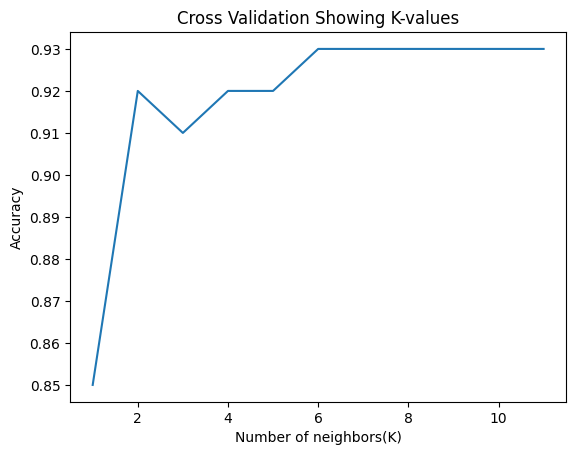

In [28]:
plt.plot(knn_results['k'], knn_results['accuracy'])
plt.title("Cross Validation Showing K-values");
plt.xlabel('Number of neighbors(K)')
plt.ylabel('Accuracy');

In [29]:
#knn optimal model
knn_optimal = Pipeline([ 
    ('scaler' , preprocessing.StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=7)),
])
knn_optimal.fit(X_val, y_val)

In [34]:
proba = knn_optimal.predict_proba(X_val)[:, 1] #this is a vector put it in a df so we can sort the values

lift_df = pd.DataFrame({
    'actual': y_val,
    'probability': proba
})
#sort those probability values
lift_df = lift_df.sort_values(by='probability', ascending=False)
lift_df

,actual,probability
2839,0,0.428571
455,1,0.428571
1685,0,0.428571
1610,0,0.428571
597,1,0.428571
...,...,...
722,0,0.000000
242,0,0.000000
3547,0,0.000000
3720,0,0.000000


In [36]:
#https://www.geeksforgeeks.org/data-analysis/understanding-gain-chart-and-lift-chart/ This website help me understand what a lift curve is.
#I used AI to help me implement the lift equation for this data. 

#lift equation: Lift= Cumulative number of positive observations upto decile i using random model/
                     #Cumulative number of positive observations upto decile i using ML model

lift_df['cumulative_actual'] = lift_df['actual'].cumsum() #cumulative sum is stacking percents together by adding them one by one.
#We do this to get a steady rate in the plot.

total_positives = lift_df['actual'].sum() 

#the cumulative gain tells us how many customers we can potentially find and target based on the cumsum
lift_df['cumulative_gain'] = ( 
    lift_df['cumulative_actual'] / total_positives
)

#shows where in the ranking order of customers are you (first being very likely; last being not likely)
lift_df['percent_customers'] = ( 
    (np.arange(len(lift_df)) + 1) / len(lift_df)
)

lift_df['lift'] = (
    lift_df['cumulative_gain'] /
    lift_df['percent_customers']
)

lift_df.head(10)

,actual,probability,cumulative_actual,cumulative_gain,percent_customers,lift
2839,0,0.428571,0,0.000000,0.000714,0.000000
455,1,0.428571,1,0.009804,0.001429,6.862745
1685,0,0.428571,1,0.009804,0.002143,4.575163
1610,0,0.428571,1,0.009804,0.002857,3.431373
597,1,0.428571,2,0.019608,0.003571,5.490196
2060,0,0.428571,2,0.019608,0.004286,4.575163
3927,1,0.428571,3,0.029412,0.005000,5.882353
3261,0,0.428571,3,0.029412,0.005714,5.147059
2987,1,0.428571,4,0.039216,0.006429,6.100218
664,1,0.428571,5,0.049020,0.007143,6.862745


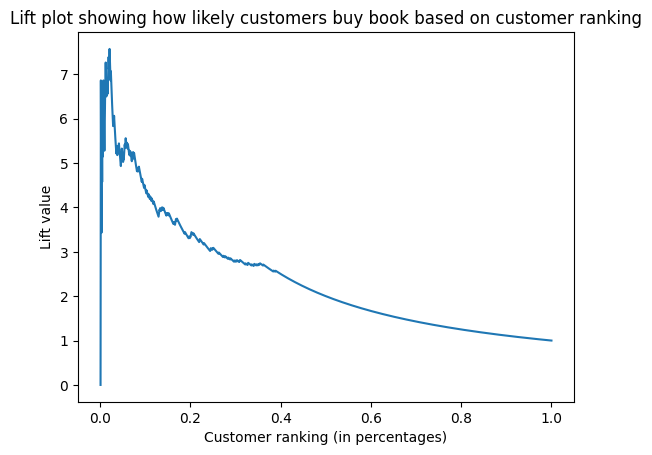

In [42]:
plt.plot(lift_df['percent_customers'] ,lift_df['lift'])
plt.title("Lift plot showing how likely customers buy book based on customer ranking")
plt.xlabel('Customer ranking (in percentages)')
plt.ylabel('Lift value'); 